In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

In [2]:
df = pd.read_csv("cleaned_data.csv")

print(df.head())
print("\nColumns:")
print(df.columns)
print("\nShape:", df.shape)

  transmission   mileage    tax   mpg fuel type  engine size  price_cad  \
0    Automatic   44900.0  160.0  46.3    Petrol          1.6    18390.8   
1    Automatic   88200.0  125.0  58.9    Diesel          2.1    12870.8   
2    Automatic  115000.0  145.0  54.3    Diesel          2.1    13790.8   
3    Automatic   69250.0  150.0  53.3    Diesel          2.1    16550.8   
4    Automatic   49850.0   30.0  62.8    Diesel          2.1    27590.8   

   car_age  
0     13.0  
1     14.0  
2     14.0  
3     15.0  
4     11.0  

Columns:
Index(['transmission', 'mileage', 'tax', 'mpg', 'fuel type', 'engine size',
       'price_cad', 'car_age'],
      dtype='object')

Shape: (3898, 8)


In [3]:
X = df.drop("price_cad", axis=1)
y = df["price_cad"]

print("Feature columns:")
print(X.columns.tolist())

print("\nTarget column:")
print(y.name)

Feature columns:
['transmission', 'mileage', 'tax', 'mpg', 'fuel type', 'engine size', 'car_age']

Target column:
price_cad


In [4]:
numeric_features = ["mileage", "tax", "mpg", "engine size", "car_age"]
categorical_features = ["transmission", "fuel type"]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['mileage', 'tax', 'mpg', 'engine size', 'car_age']
Categorical features: ['transmission', 'fuel type']


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (3118, 7)
X_test shape: (780, 7)


In [6]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder="passthrough"
)

In [7]:
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ))
])

In [8]:
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [9]:
y_pred = rf_model.predict(X_test)

results = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

print(results.head(10))

   Actual Price  Predicted Price
0      79101.60       83335.0536
1      57958.16       56524.8368
2      36606.80       44791.8560
3      37350.16       36550.0544
4      36790.80       44861.6840
5      41887.60       39833.5712
6      45352.32       41579.6208
7      43056.00       37380.0968
8      40112.00       39457.1072
9      47376.32       45324.3060


In [10]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("Random Forest Regression Performance Metrics")
print(f"R²   : {r2:.4f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")

Random Forest Regression Performance Metrics
R²   : 0.9383
MSE  : 18774301.83
RMSE : 4332.93


In [11]:
n_values = [50, 100, 200, 300]

r2_scores = []
mse_scores = []
rmse_scores = []

for n in n_values:
    rf_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=n,
            random_state=42
        ))
    ])
    
    rf_pipeline.fit(X_train, y_train)
    y_pred_n = rf_pipeline.predict(X_test)
    
    r2_n = r2_score(y_test, y_pred_n)
    mse_n = mean_squared_error(y_test, y_pred_n)
    rmse_n = np.sqrt(mse_n)
    
    r2_scores.append(r2_n)
    mse_scores.append(mse_n)
    rmse_scores.append(rmse_n)

rf_results = pd.DataFrame({
    "n_estimators": n_values,
    "R2": r2_scores,
    "MSE": mse_scores,
    "RMSE": rmse_scores
})

print(rf_results)

   n_estimators        R2           MSE         RMSE
0            50  0.938480  1.871320e+07  4325.875814
1           100  0.938279  1.877430e+07  4332.932243
2           200  0.939479  1.840938e+07  4290.615711
3           300  0.939602  1.837207e+07  4286.264992


In [12]:
best_row = rf_results.loc[rf_results["R2"].idxmax()]

print("Best Random Forest setting based on highest R²:")
print(best_row)

Best Random Forest setting based on highest R²:
n_estimators    3.000000e+02
R2              9.396015e-01
MSE             1.837207e+07
RMSE            4.286265e+03
Name: 3, dtype: float64


In [13]:
best_n = int(best_row["n_estimators"])

final_rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=best_n,
        random_state=42
    ))
])

final_rf_model.fit(X_train, y_train)
final_y_pred = final_rf_model.predict(X_test)

final_r2 = r2_score(y_test, final_y_pred)
final_mse = mean_squared_error(y_test, final_y_pred)
final_rmse = np.sqrt(final_mse)

print(f"Final Random Forest Model (n_estimators={best_n})")
print(f"R²   : {final_r2:.4f}")
print(f"MSE  : {final_mse:.2f}")
print(f"RMSE : {final_rmse:.2f}")

Final Random Forest Model (n_estimators=300)
R²   : 0.9396
MSE  : 18372067.58
RMSE : 4286.26


In [14]:
comparison_df = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": final_y_pred,
    "Difference": y_test.values - final_y_pred
})

print(comparison_df.head(15))

    Actual Price  Predicted Price    Difference
0       79101.60     81931.556800  -2829.956800
1       57958.16     56754.787733   1203.372267
2       36606.80     44703.597333  -8096.797333
3       37350.16     36526.741600    823.418400
4       36790.80     45568.526133  -8777.726133
5       41887.60     40043.435467   1844.164533
6       45352.32     41200.629867   4151.690133
7       43056.00     38003.924267   5052.075733
8       40112.00     39288.961867    823.038133
9       47376.32     45349.620311   2026.699689
10      26770.16     29245.794133  -2475.634133
11      81254.40     59324.607378  21929.792622
12      42872.00     36998.192533   5873.807467
13      27222.80     21645.753867   5577.046133
14      48758.16     49049.812267   -291.652267


In [16]:
# Get the trained Random Forest model from the pipeline
rf_trained = final_rf_model.named_steps["model"]

# Get encoded feature names
encoded_cat_names = final_rf_model.named_steps["preprocessor"] \
    .named_transformers_["cat"] \
    .get_feature_names_out(categorical_features)

all_feature_names = list(encoded_cat_names) + numeric_features

# Feature importances
importances = rf_trained.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feature_importance_df)

                   Feature  Importance
8                  mileage    0.523969
10                     mpg    0.218985
12                 car_age    0.117336
11             engine size    0.113933
9                      tax    0.011115
1      transmission_Manual    0.005235
3   transmission_Semi-Auto    0.003109
0   transmission_Automatic    0.002823
4         fuel type_Diesel    0.001781
7         fuel type_Petrol    0.000969
5         fuel type_Hybrid    0.000739
2       transmission_Other    0.000004
6          fuel type_Other    0.000001


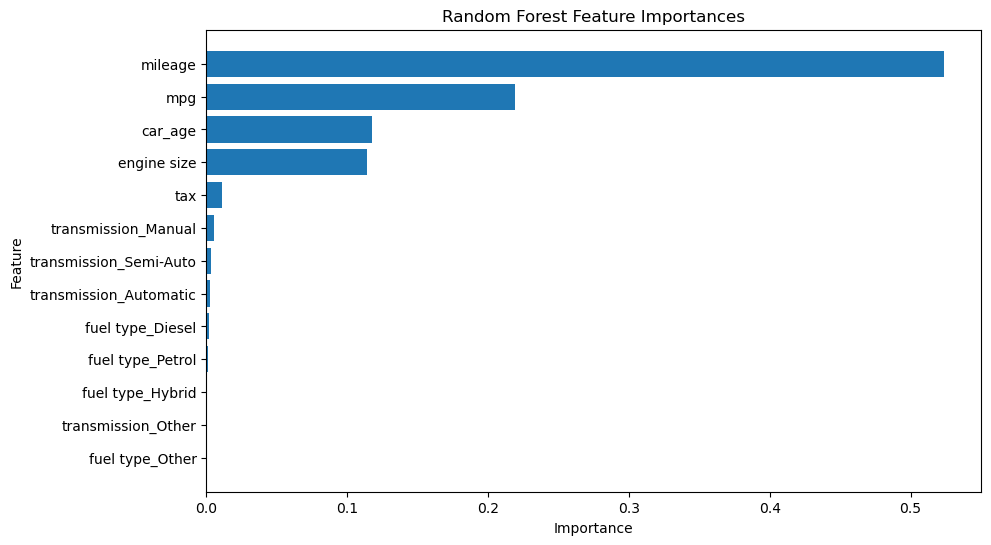

In [17]:
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df["Feature"], feature_importance_df["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importances")
plt.gca().invert_yaxis()
plt.show()

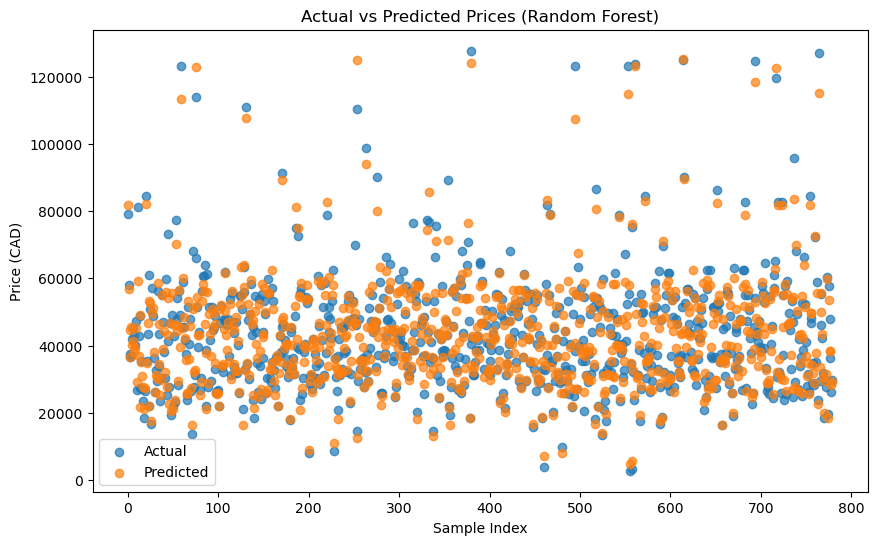

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# Actual values (blue)
plt.scatter(range(len(y_test)), y_test, label="Actual", alpha=0.7)

# Predicted values (red)
plt.scatter(range(len(final_y_pred)), final_y_pred, label="Predicted", alpha=0.7)

plt.xlabel("Sample Index")
plt.ylabel("Price (CAD)")
plt.title("Actual vs Predicted Prices (Random Forest)")

plt.legend()
plt.show()

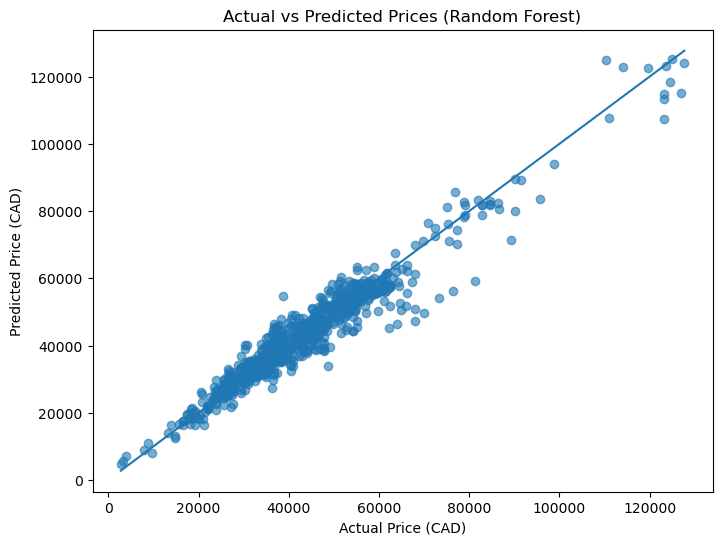

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# Scatter points
plt.scatter(y_test, final_y_pred, alpha=0.6)

# Perfect prediction line (y = x)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
)

plt.xlabel("Actual Price (CAD)")
plt.ylabel("Predicted Price (CAD)")
plt.title("Actual vs Predicted Prices (Random Forest)")

plt.show()